In [48]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import (KMeans, AgglomerativeClustering)
from scipy.cluster.hierarchy import (dendrogram, cut_tree)
from sklearn.decomposition import PCA

In [17]:
wine = pd.read_csv('/home/dsamuelchin/Documents/Data 645/Unit 8/winequality_red.csv')

Basic Information

In [4]:
wine.shape

(1599, 12)

In [11]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   fixed_acidity        1599 non-null   float64
 1   volatile_acidity     1599 non-null   float64
 2   citric_acid          1599 non-null   float64
 3   residual_sugar       1599 non-null   float64
 4   chlorides            1599 non-null   float64
 5   fre_sulfur_dioxide   1599 non-null   float64
 6   totalsulfur_dioxide  1599 non-null   float64
 7   density              1599 non-null   float64
 8   pH                   1599 non-null   float64
 9   sulphates            1599 non-null   float64
 10  alcohol              1599 non-null   float64
 11  quality              1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [16]:
wine.isna().sum()

fixed_acidity          0
volatile_acidity       0
citric_acid            0
residual_sugar         0
chlorides              0
fre_sulfur_dioxide     0
totalsulfur_dioxide    0
density                0
pH                     0
sulphates              0
alcohol                0
quality                0
dtype: int64

In [14]:
wine.describe()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,fre_sulfur_dioxide,totalsulfur_dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [19]:
wine.head(10)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,fre_sulfur_dioxide,totalsulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


Basic Visualizations

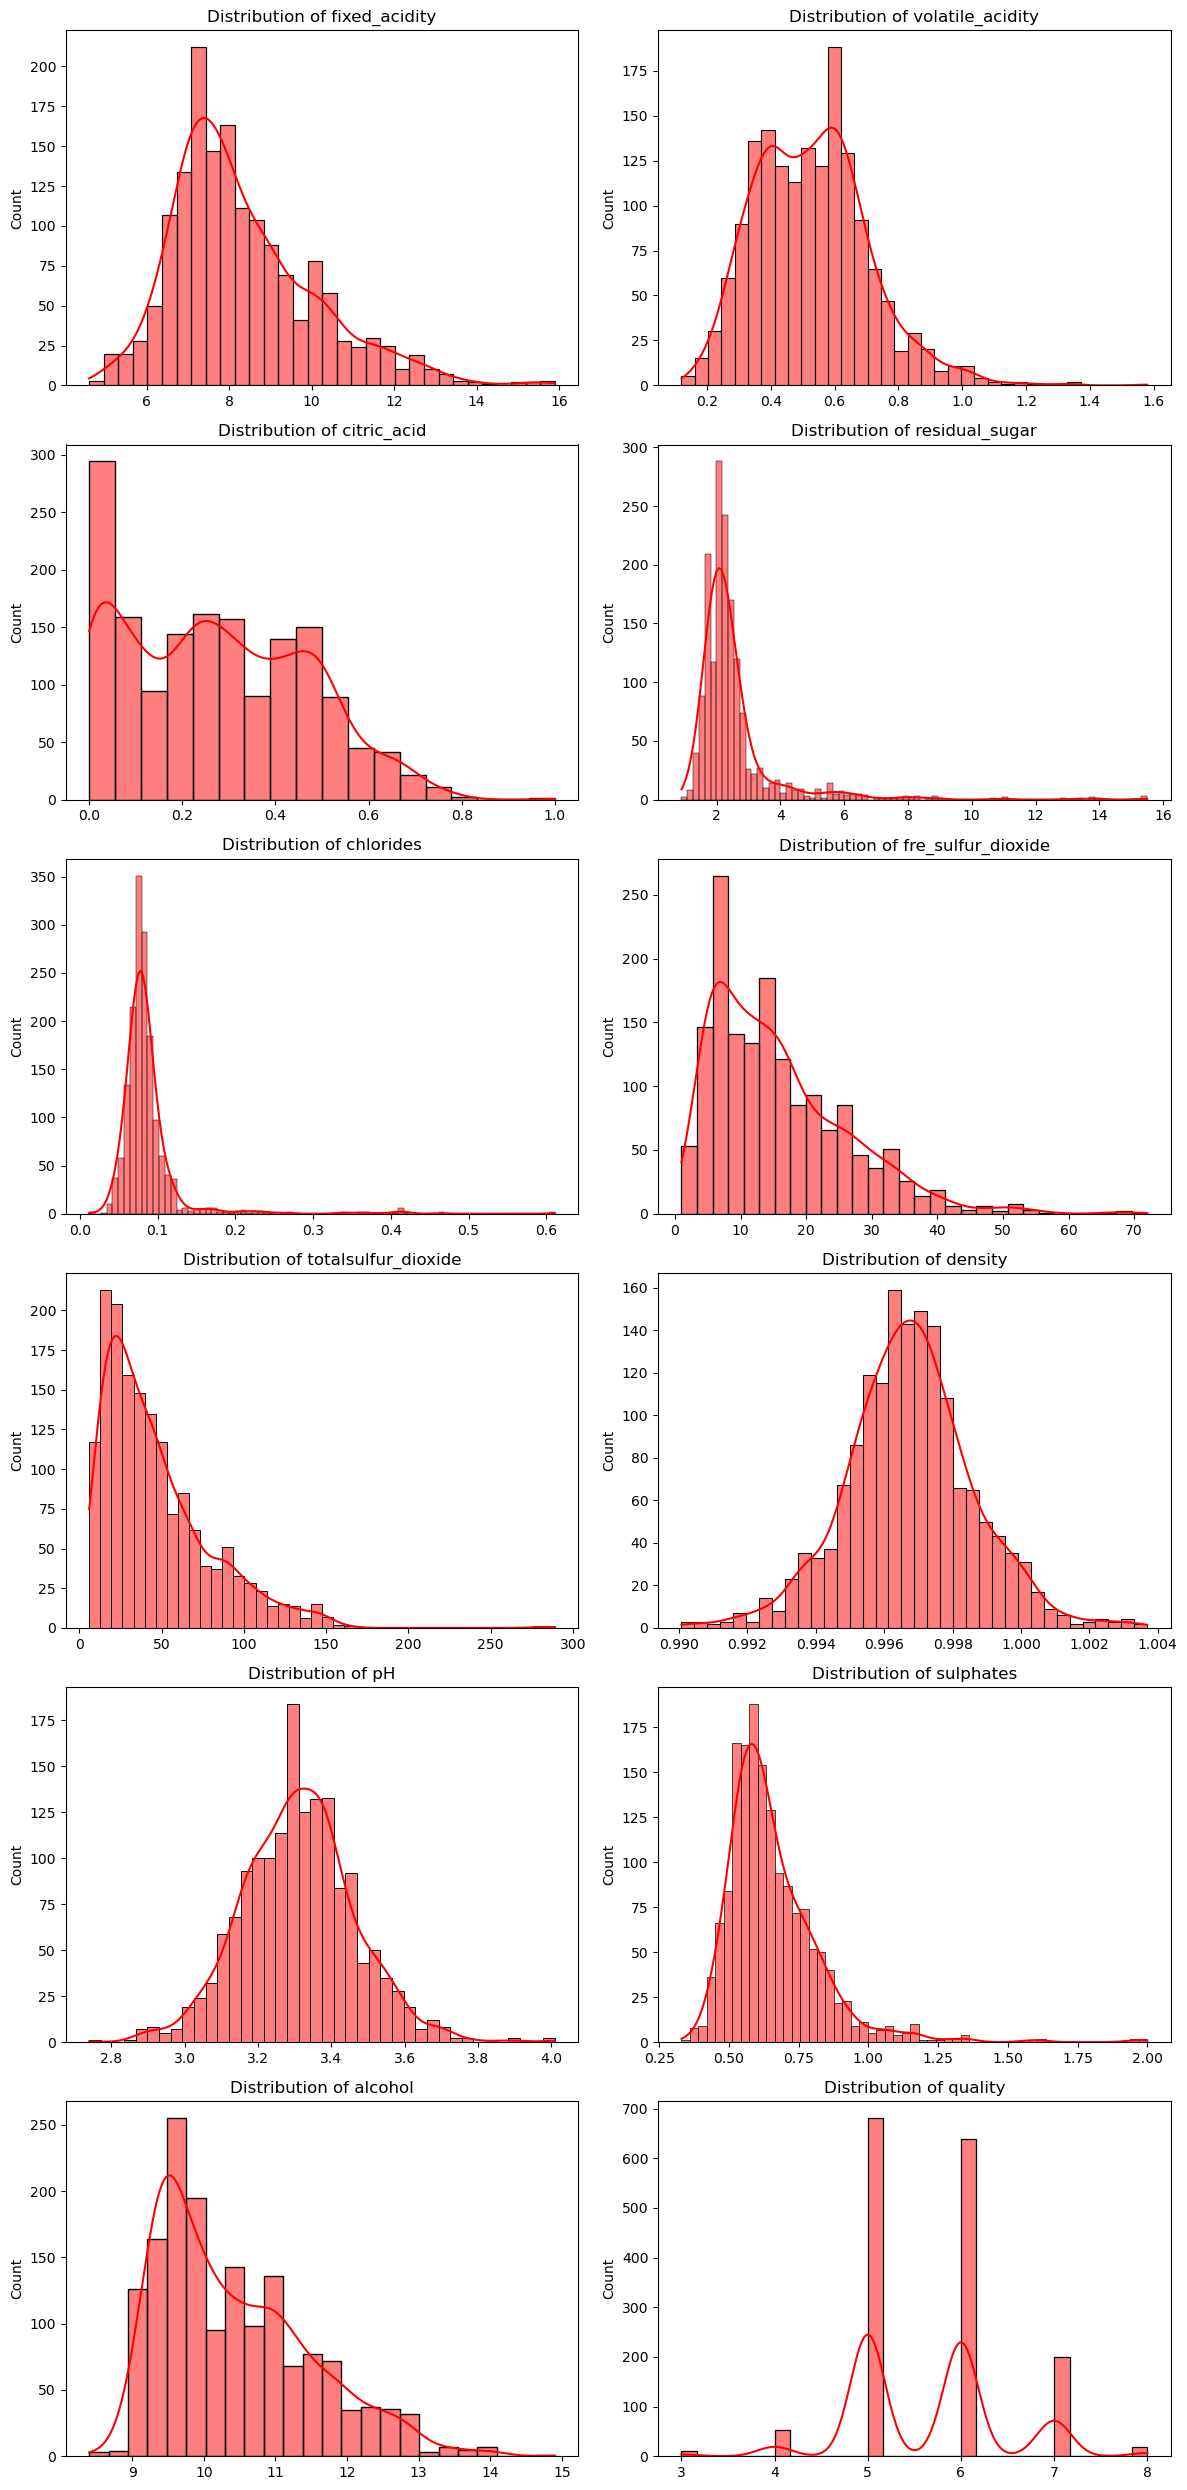

In [27]:
cols = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'fre_sulfur_dioxide', 'totalsulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality']
fig, axes = plt.subplots(6,2, figsize=(12,25))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(wine[col], kde=True, ax=axes[i], color='red', shrink=1)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('') 
for j in range(i + 1, len(axes)):
    axes[j].axis('off') 

plt.tight_layout()
plt.savefig('columns_dist.png', dpi=300, bbox_inches='tight') 
plt.show()

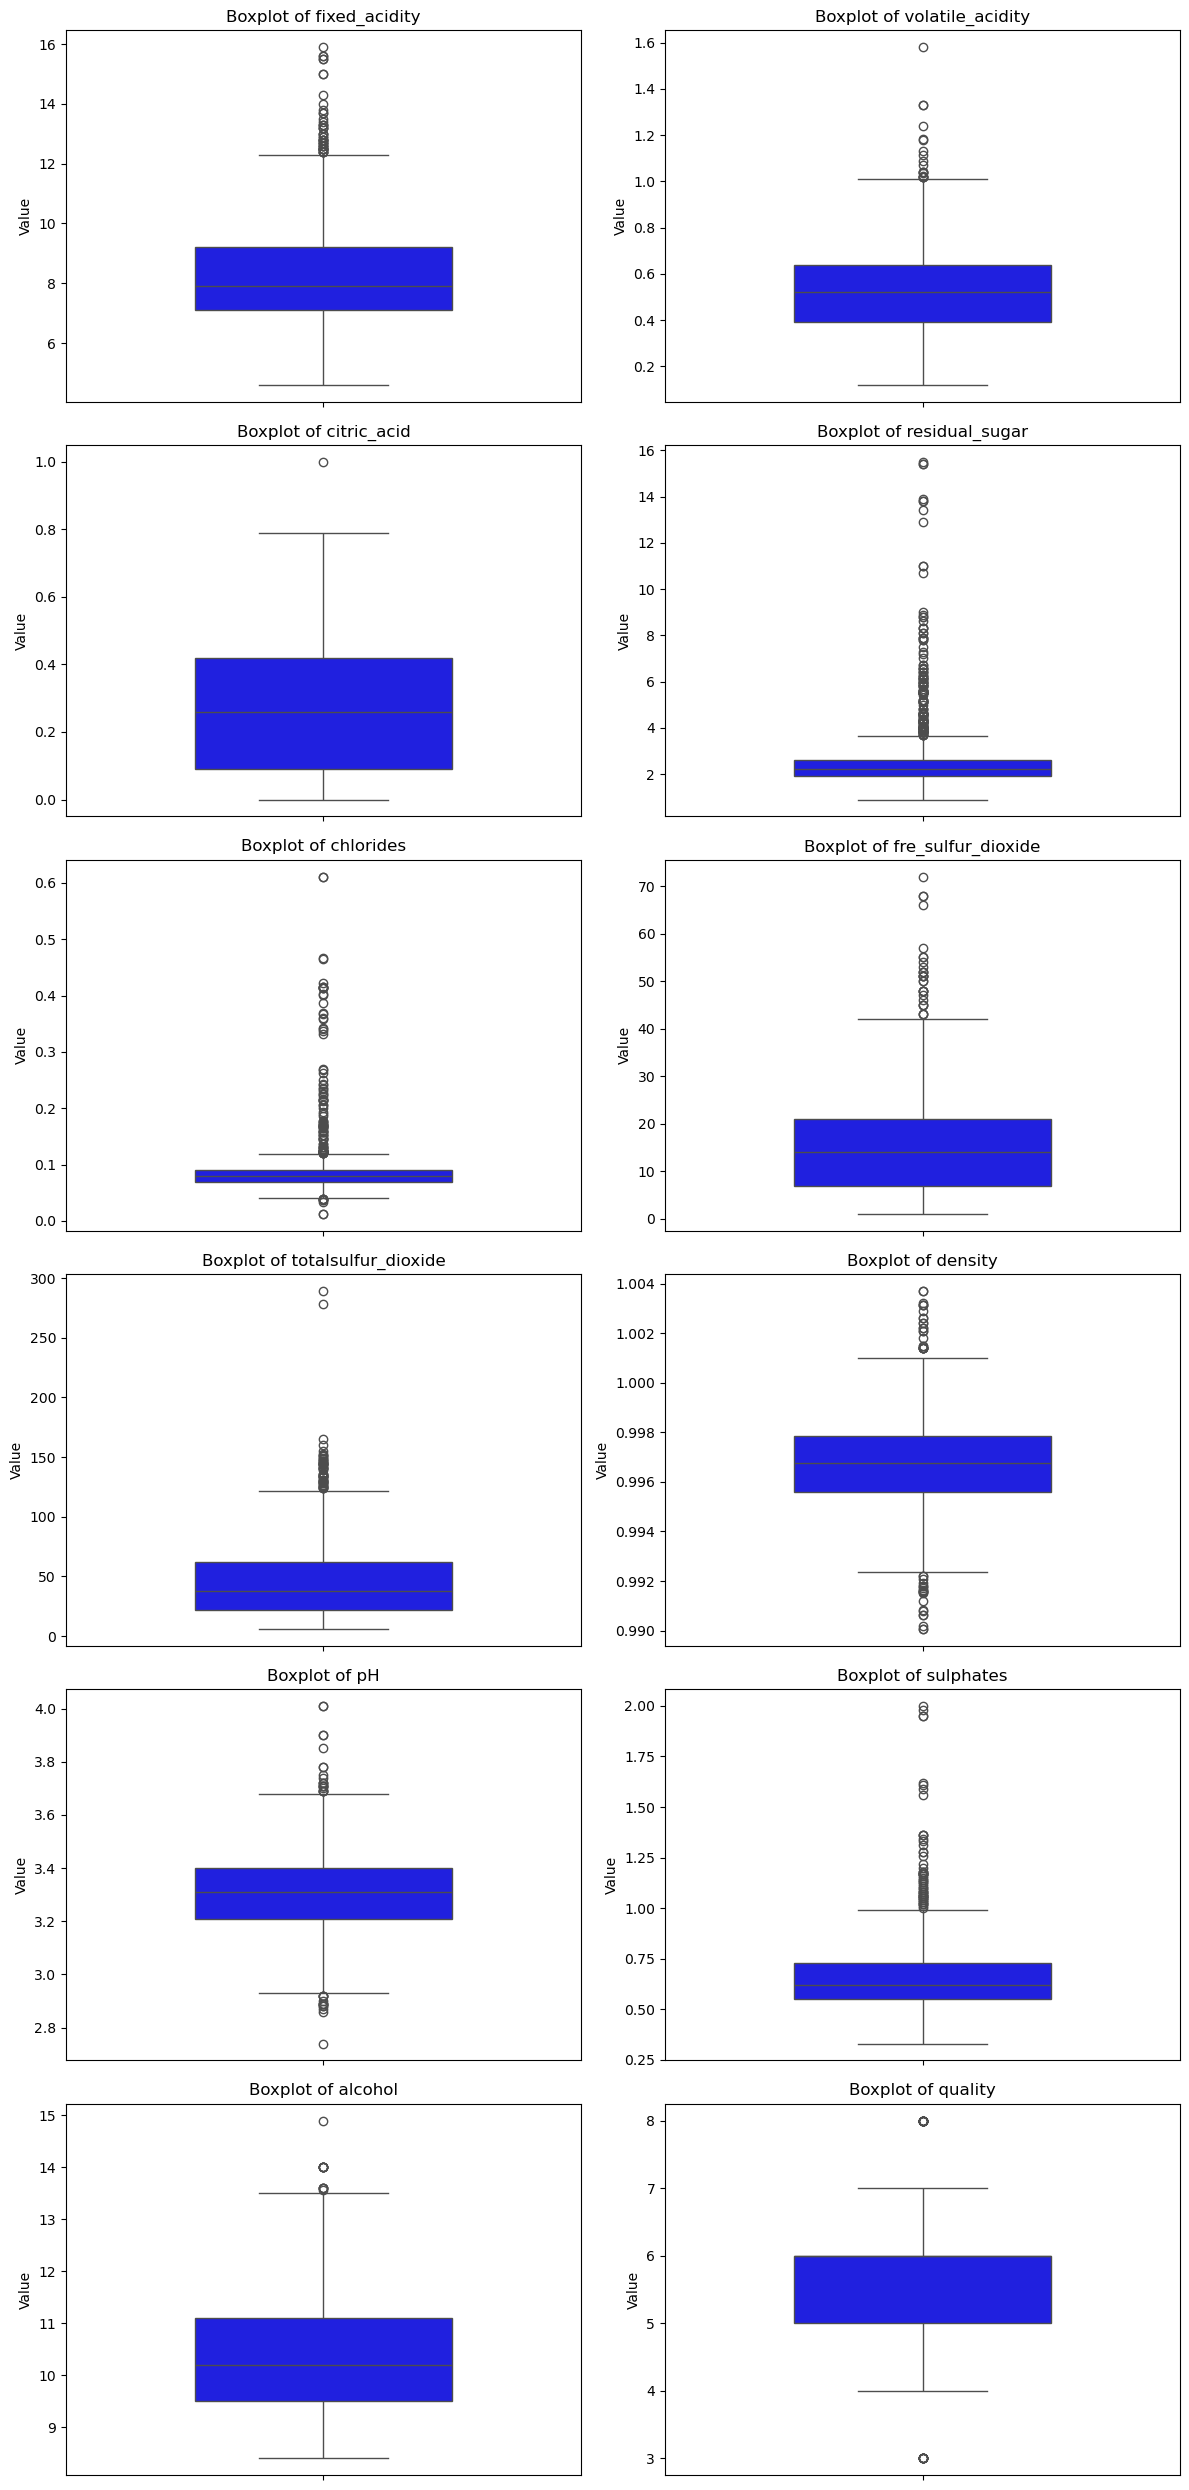

In [30]:
fig, axes = plt.subplots(6,2, figsize=(12,25))
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.boxplot(y=wine[col], ax=axes[i], color='blue', width=0.5)
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('Value')
plt.tight_layout()
plt.savefig('Boxplots of Columns.png', dpi=300)
plt.show()

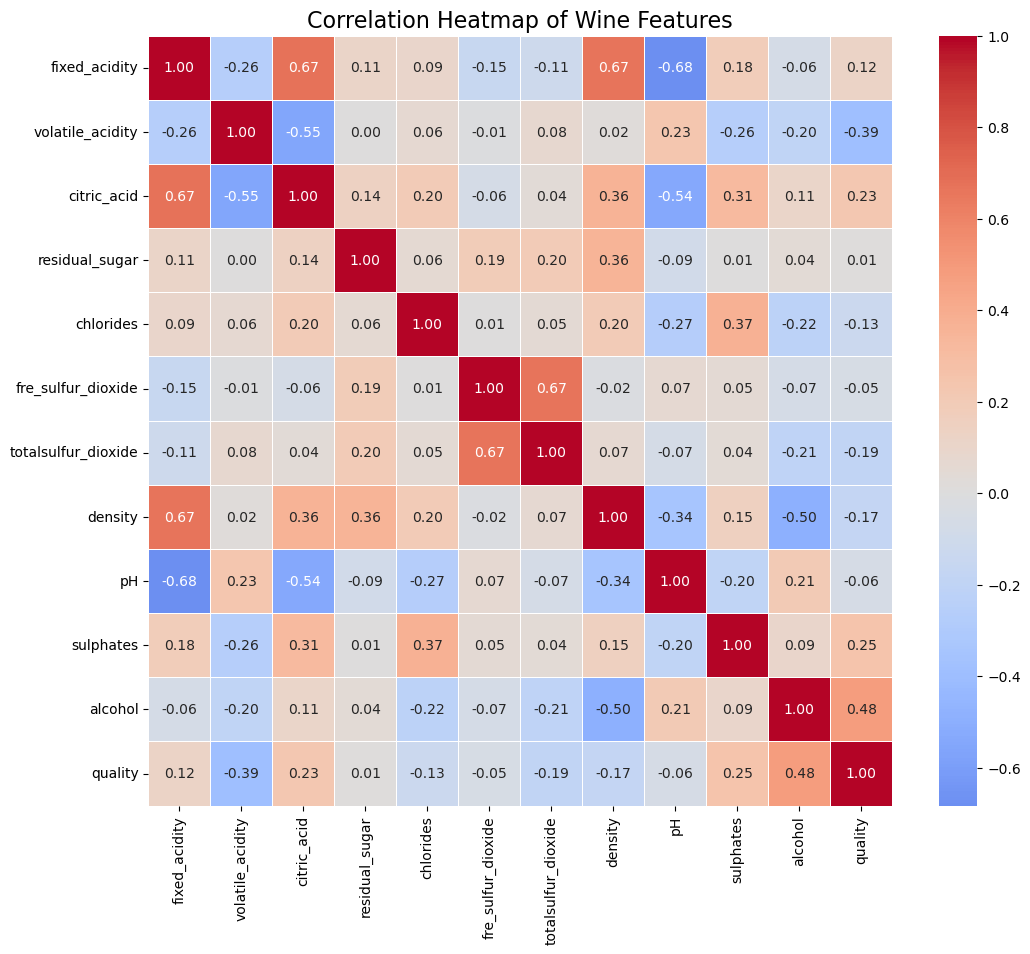

In [35]:
corr = wine.corr()
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, linewidths=.5, linecolor='white', fmt=".2f")
plt.title('Correlation Heatmap of Wine Features', fontsize=16)
plt.show()

Preprocessing (Applying StandardScaler)

In [36]:
X = wine.drop('quality', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Applying K-Means

In [37]:
kmeans = KMeans(n_clusters=3, random_state=42)
wine['cluster'] = kmeans.fit_predict(X_scaled)

Implementing Elbow Method

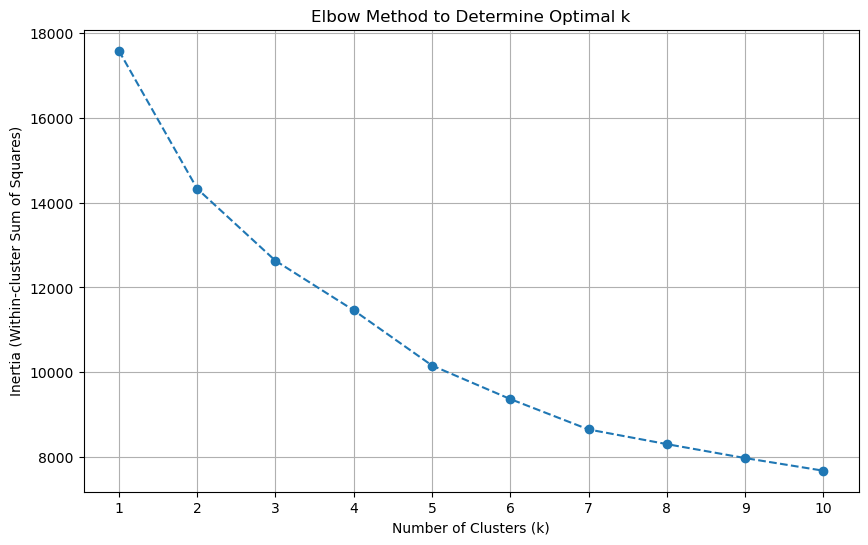

In [44]:
inertia = []
K_range = range(1,11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10,6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal k') 
plt.xlabel('Number of Clusters (k)') 
plt.ylabel('Inertia (Within-cluster Sum of Squares)') 
plt.xticks(K_range)
plt.grid(True)
plt.show()

Grouping and Profiling the Clusters

In [52]:
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
wine['cluster'] = final_kmeans.fit_predict(X_scaled)

description = wine.groupby('cluster').mean()
description['count'] = wine.groupby('cluster')['quality'].count()
print(description)
description.to_csv('cluster_profiles_original_units.csv')

         fixed_acidity  volatile_acidity  citric_acid  residual_sugar  \
cluster                                                                 
0             7.189889          0.609342     0.123047        2.214058   
1            10.067131          0.405080     0.469761        2.582570   
2             8.155467          0.535173     0.289680        3.105467   

         chlorides  fre_sulfur_dioxide  totalsulfur_dioxide   density  \
cluster                                                                 
0         0.078553           13.507618            34.894737  0.995896   
1         0.100460           10.888446            30.627490  0.997574   
2         0.087235           27.108000            89.954667  0.997276   

               pH  sulphates    alcohol   quality  count  
cluster                                                   
0        3.405762   0.609224  10.494044  5.552632    722  
1        3.195040   0.752131  10.724037  5.960159    502  
2        3.284267   0.626533   9

Cluster Plots

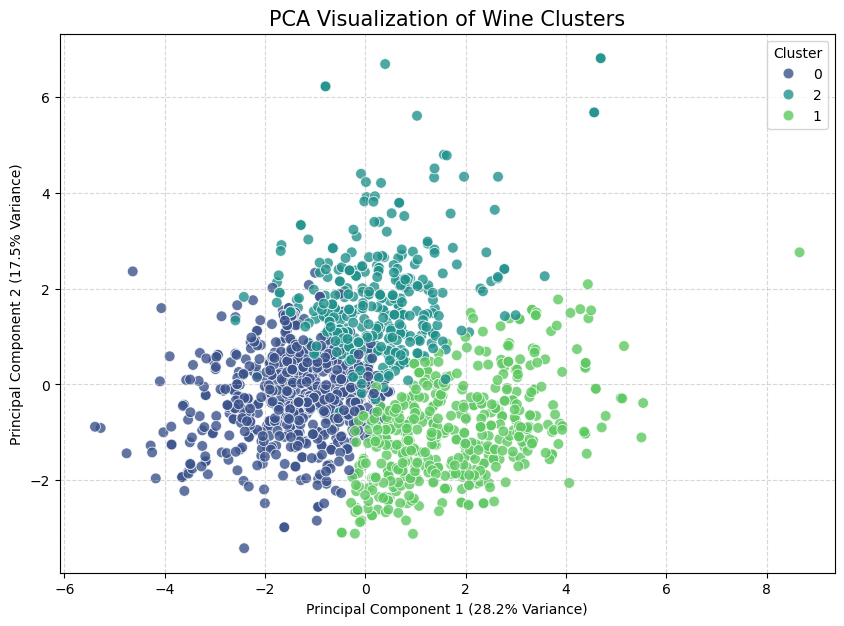

In [51]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['cluster'] = wine['cluster'].astype(str)

plt.figure(figsize=(10,7))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='viridis', s=60, alpha=0.8)

plt.title('PCA Visualization of Wine Clusters', fontsize=15)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Quantifying Results

In [ ]:
print(f"Total Within-Cluster Sum of Squares (Inertia): {final_kmeans.inertia_:.2f}")

cluster_quality_dist = pd.crosstab(wine['cluster'], wine['quality'])
print("Quality Distribution per Cluster:")
print(cluster_quality_dist)

tss = np.sum((X_scaled - X_scaled.mean(axis=0))**2)

wss = final_kmeans.inertia_
bss = tss - wss
pve_clusters = (bss / tss) * 100

print(f"Proportion of Variance Explained by Clusters: {pve_clusters:.2f}%")

Total Within-Cluster Sum of Squares (Inertia): 12629.97
Quality Distribution per Cluster:
quality  3   4    5    6    7   8
cluster                          
0        7  38  303  304   63   7
1        3   9  135  223  122  10
2        0   6  243  111   14   1
Proportion of Variance Explained by Clusters: 28.19%
